# 01 — Preprocesamiento

Genera los datasets procesados y los sube a `gs://tfm-twitter-processed/`.

**Ejecutar antes de cualquier otro notebook.**

| Input | Output GCS |
|-------|------------|
| HuggingFace `tweet_eval/sentiment` | `tweeteval/sentiment/{train,val,test}.parquet` |
| HuggingFace `tweet_eval/stance_*` (×5) | `tweeteval/stance_*/{train,val,test}.parquet` |
| GCS `tfm-twitter-raw/` (scraped) | `scraped/{campaign}.parquet` |
| `electoral_campaigns/trump_2016/tweets.csv` | `candidate_tweets/trump_2016.parquet` |

**Decisiones metodológicas:**
- Variante A (BERTweet-style): `@user → @USER`, `URL → HTTPURL` — usada para fine-tuning
- `#semst` eliminado del split stance (artefacto SemEval-2016)
- Re-split estratificado train+val → 90/10 (val stance TweetEval tiene 40-70 muestras, alta varianza)
- Deduplicación por `id` en datos scrapeados (campaña españa_2023 re-ejecutada por DNS failure)

Ref: Nguyen et al. (2020) BERTweet; Barbieri et al. (2020) TweetEval.

In [2]:
import sys
from pathlib import Path

# Limpiar módulos cacheados
for key in list(sys.modules.keys()):
    if 'pipeline' in key:
        del sys.modules[key]

# Re-añadir src/ al path
_cwd = Path().resolve()
_root = _cwd
for _ in range(6):
    if (_root / 'src').exists() and (_root / 'notebooks').exists():
        break
    _root = _root.parent
src_path = str(_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from pipeline.savers import save_tweeteval_splits, save_scraped_campaign, save_candidate_tweets, PROCESSED_BUCKET
from pipeline.preprocessing import preprocess_df
print("OK")


OK


In [3]:
import sys
from pathlib import Path

# Find TFM root regardless of where jupyter was launched from
_cwd = Path().resolve()
_root = _cwd
for _ in range(6):
    if (_root / 'src').exists() and (_root / 'notebooks').exists():
        break
    _root = _root.parent
assert (_root / 'src').exists(), f"Could not find src/ from {_cwd}"
sys.path.insert(0, str(_root / 'src'))
print(f'src → {_root / "src"}')

from pipeline.preprocessing import (
    normalize_tweet_bertweet,
    preprocess_tweeteval_sentiment,
    preprocess_tweeteval_stance,
    preprocess_df,
    preprocess_scraped_batch,
)
from pipeline.loaders import (
    load_tweeteval,
    stratified_resplit,
    load_scraped_from_gcs,
    deduplicate_tweets,
    load_candidate_tweets_csv,
    TWEETEVAL_STANCE_TASKS,
)
from pipeline.savers import (
    save_tweeteval_splits,
    save_scraped_campaign,
    save_candidate_tweets,
    PROCESSED_BUCKET,
)

import pandas as pd

RAW_BUCKET = 'tfm-twitter-raw'
CAMPAIGNS = ['brexit_2016', 'trump_2016', 'trump_2024', 'españa_2023']
CANDIDATE_CSV = str(_root / 'electoral_campaigns' / 'trump_2016' / 'tweets.csv')

print(f'Processed bucket: gs://{PROCESSED_BUCKET}/')

src → /Users/jimenamillamoreno/Desktop/TFM/TFM/src
Processed bucket: gs://tfm-twitter-processed/


## 1. TweetEval Sentiment

In [4]:
print('Loading TweetEval sentiment...')
sent_splits = load_tweeteval('sentiment')

for split_name, df in sent_splits.items():
    print(f'  {split_name}: {len(df):,} tweets | labels: {df["label"].value_counts().to_dict()}')

Loading TweetEval sentiment...


  train: 45,615 tweets | labels: {'neutral': 20673, 'positive': 17849, 'negative': 7093}
  validation: 2,000 tweets | labels: {'neutral': 869, 'positive': 819, 'negative': 312}
  test: 12,284 tweets | labels: {'neutral': 5937, 'negative': 3972, 'positive': 2375}


In [5]:
# Apply BERTweet normalization
for split_name in sent_splits:
    sent_splits[split_name] = preprocess_df(
        sent_splits[split_name],
        text_col='text',
        variant='bertweet',
        is_stance=False,
    )

# Verify normalization on a sample
sample = sent_splits['train'].sample(3, random_state=42)
sample[['text', 'label']]

,text,label
11449,I forgot all about Ice Cube being in the movie...,negative
26433,playoffs are finally set. Chardon plays warren...,neutral
33669,Are we just going to ignore the fact that Ice ...,neutral


In [6]:
# Stratified re-split train+val → 90/10
print('Val size BEFORE re-split:', len(sent_splits['validation']))

sent_splits['train'], sent_splits['validation'] = stratified_resplit(
    sent_splits['train'],
    sent_splits['validation'],
    val_size=0.1,
)

print('Val size AFTER re-split:', len(sent_splits['validation']))
print('Train size:', len(sent_splits['train']))

# Label distribution in new splits
for split_name, df in sent_splits.items():
    dist = df['label'].value_counts(normalize=True).round(3).to_dict()
    print(f'  {split_name}: {dist}')

Val size BEFORE re-split: 2000
Val size AFTER re-split: 4762
Train size: 42853
  train: {'neutral': 0.452, 'positive': 0.392, 'negative': 0.156}
  validation: {'neutral': 0.452, 'positive': 0.392, 'negative': 0.156}
  test: {'neutral': 0.483, 'negative': 0.323, 'positive': 0.193}


In [7]:
# Save to GCS
uris = save_tweeteval_splits(sent_splits, task='sentiment')
print('Saved:', uris)

Saved 42,853 rows → gs://tfm-twitter-processed/tweeteval/sentiment/train.parquet
Saved 4,762 rows → gs://tfm-twitter-processed/tweeteval/sentiment/validation.parquet
Saved 12,284 rows → gs://tfm-twitter-processed/tweeteval/sentiment/test.parquet
Saved: {'train': 'gs://tfm-twitter-processed/tweeteval/sentiment/train.parquet', 'validation': 'gs://tfm-twitter-processed/tweeteval/sentiment/validation.parquet', 'test': 'gs://tfm-twitter-processed/tweeteval/sentiment/test.parquet'}


## 2. TweetEval Stance (5 tópicos)

In [8]:
stance_processed = {}

for task in TWEETEVAL_STANCE_TASKS:
    print(f'\nProcessing {task}...')
    splits = load_tweeteval(task)

    for split_name, df in splits.items():
        print(f'  {split_name}: {len(df)} tweets | {df["label"].value_counts().to_dict()}')

    # BERTweet + remove #semst
    for split_name in splits:
        splits[split_name] = preprocess_df(
            splits[split_name],
            text_col='text',
            variant='bertweet',
            is_stance=True,  # removes #semst
        )

    # Stratified re-split (val is 40-70 rows — high variance)
    splits['train'], splits['validation'] = stratified_resplit(
        splits['train'], splits['validation'], val_size=0.1
    )
    print(f'  After re-split → train: {len(splits["train"])}, val: {len(splits["validation"])}')

    # Save
    save_tweeteval_splits(splits, task=task)
    stance_processed[task] = splits

print('\nAll stance tasks processed.')


Processing stance_abortion...
  train: 587 tweets | {'favor': 319, 'against': 159, 'neither': 109}
  validation: 66 tweets | {'favor': 36, 'against': 18, 'neither': 12}
  test: 280 tweets | {'favor': 189, 'neither': 46, 'against': 45}
  After re-split → train: 587, val: 66
Saved 587 rows → gs://tfm-twitter-processed/tweeteval/stance_abortion/train.parquet
Saved 66 rows → gs://tfm-twitter-processed/tweeteval/stance_abortion/validation.parquet
Saved 280 rows → gs://tfm-twitter-processed/tweeteval/stance_abortion/test.parquet

Processing stance_atheism...
  train: 461 tweets | {'favor': 273, 'against': 105, 'neither': 83}
  validation: 52 tweets | {'favor': 31, 'against': 12, 'neither': 9}
  test: 220 tweets | {'favor': 160, 'neither': 32, 'against': 28}
  After re-split → train: 461, val: 52
Saved 461 rows → gs://tfm-twitter-processed/tweeteval/stance_atheism/train.parquet
Saved 52 rows → gs://tfm-twitter-processed/tweeteval/stance_atheism/validation.parquet
Saved 220 rows → gs://tfm-tw

## 3. Scraped tweets (GCS raw → processed)

In [9]:
for campaign in CAMPAIGNS:
    print(f'\nLoading {campaign}...')
    try:
        df = load_scraped_from_gcs(bucket=RAW_BUCKET, campaign=campaign)
        print(f'  Loaded: {len(df):,} rows')
    except Exception as e:
        print(f'  ERROR: {e}')
        continue

    # Deduplicate by tweet id
    id_col = 'id' if 'id' in df.columns else 'tweet_id'
    df = deduplicate_tweets(df, id_col=id_col)

    # Select and rename key columns
    text_col = 'rawContent' if 'rawContent' in df.columns else 'text'
    keep_cols = [c for c in [id_col, text_col, 'date', 'lang', 'likeCount',
                              'retweetCount', 'replyCount', '_query', 'campaign']
                 if c in df.columns]
    df = df[keep_cols].copy()
    if text_col != 'text':
        df = df.rename(columns={text_col: 'text'})

    # BERTweet normalization
    df = preprocess_df(df, text_col='text', variant='bertweet', output_col='text_clean')

    # Campaign label
    if 'campaign' not in df.columns:
        df['campaign'] = campaign

    print(f'  Final: {len(df):,} unique tweets')
    save_scraped_campaign(df, campaign=campaign)


Loading brexit_2016...
  Loaded: 77,067 rows
Deduplicated: 77067 → 75537 tweets (removed 1530)
  Final: 75,537 unique tweets
Saved 75,537 rows → gs://tfm-twitter-processed/scraped/brexit_2016.parquet

Loading trump_2016...
  Loaded: 46,328 rows
Deduplicated: 46328 → 45117 tweets (removed 1211)
  Final: 45,117 unique tweets
Saved 45,117 rows → gs://tfm-twitter-processed/scraped/trump_2016.parquet

Loading trump_2024...
  Loaded: 76,083 rows
Deduplicated: 76083 → 69144 tweets (removed 6939)
  Final: 69,144 unique tweets
Saved 69,144 rows → gs://tfm-twitter-processed/scraped/trump_2024.parquet

Loading españa_2023...
  Loaded: 69,746 rows
Deduplicated: 69746 → 39470 tweets (removed 30276)
  Final: 39,470 unique tweets
Saved 39,470 rows → gs://tfm-twitter-processed/scraped/españa_2023.parquet


## 4. Candidate tweets (tweets.csv trump_2016)

In [10]:
df_candidates = load_candidate_tweets_csv(CANDIDATE_CSV)
print(f'Loaded: {len(df_candidates):,} candidate tweets')
print(df_candidates['handle'].value_counts())
df_candidates.head(3)

Loaded: 6,248 candidate tweets
handle
realDonaldTrump    3131
HillaryClinton     3117
Name: count, dtype: int64


,id,handle,text,is_retweet,time,lang,retweet_count,favorite_count
0,780925634159796224,HillaryClinton,The question in this election: Who can put the...,False,2016-09-28 00:22:34+00:00,en,218,651
1,780916180899037184,HillaryClinton,"Last night, Donald Trump said not paying taxes...",True,2016-09-27 23:45:00+00:00,en,2445,5308
2,780911564857761793,HillaryClinton,Couldn't be more proud of @HillaryClinton. Her...,True,2016-09-27 23:26:40+00:00,en,7834,27234


In [11]:
df_candidates = preprocess_df(df_candidates, text_col='text', variant='bertweet', output_col='text_clean')
save_candidate_tweets(df_candidates, campaign='trump_2016')
print('Done.')

Saved 6,248 rows → gs://tfm-twitter-processed/candidate_tweets/trump_2016.parquet
Done.


## 5. Resumen: tamaños y distribuciones

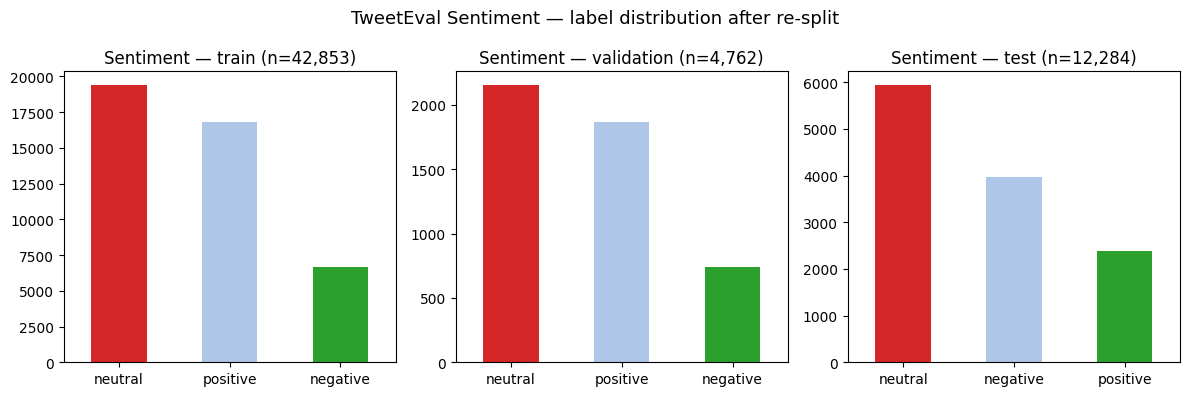

In [12]:
import matplotlib.pyplot as plt

# TweetEval sentiment label distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (split_name, df) in zip(axes, sent_splits.items()):
    df['label'].value_counts().plot(kind='bar', ax=ax, color=['#d62728', '#aec7e8', '#2ca02c'])
    ax.set_title(f'Sentiment — {split_name} (n={len(df):,})')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('TweetEval Sentiment — label distribution after re-split', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/01_sentiment_label_dist.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Summary table
rows = []
for split_name, df in sent_splits.items():
    rows.append({'task': 'sentiment', 'split': split_name, 'n': len(df),
                 **df['label'].value_counts().to_dict()})

for task, splits in stance_processed.items():
    for split_name, df in splits.items():
        rows.append({'task': task, 'split': split_name, 'n': len(df),
                     **df['label'].value_counts().to_dict()})

summary = pd.DataFrame(rows).fillna(0).astype({'n': int})
summary

,task,split,n,neutral,positive,negative,favor,against,neither
0,sentiment,train,42853,19388.0,16801.0,6664.0,0.0,0.0,0.0
1,sentiment,validation,4762,2154.0,1867.0,741.0,0.0,0.0,0.0
2,sentiment,test,12284,5937.0,2375.0,3972.0,0.0,0.0,0.0
3,stance_abortion,train,587,0.0,0.0,0.0,319.0,159.0,109.0
4,stance_abortion,validation,66,0.0,0.0,0.0,36.0,18.0,12.0
5,stance_abortion,test,280,0.0,0.0,0.0,189.0,45.0,46.0
6,stance_atheism,train,461,0.0,0.0,0.0,273.0,105.0,83.0
7,stance_atheism,validation,52,0.0,0.0,0.0,31.0,12.0,9.0
8,stance_atheism,test,220,0.0,0.0,0.0,160.0,28.0,32.0
9,stance_climate,train,355,0.0,0.0,0.0,13.0,151.0,191.0
